# 🧬 Antimicrobial Resistance (AMR) Gene Profiling
## Part 5: Screening 50 *Acinetobacter* Genomes for AMR Genes

### 🎯 Objective
Identify known antimicrobial resistance (AMR) genes across all 50 strains using **ABRicate** with the NCBI / CARD database, and generate a presence/absence matrix.

In [2]:
%%bash
source ~/miniconda3/bin/activate roary_env

# 1. Install ABRicate if not already installed
if ! command -v abricate &> /dev/null
then
    echo "🛠️ Installing ABRicate via Conda..."
    conda install -c bioconda -c conda-forge abricate -y
fi

echo "🔍 Screening 50 genomes for AMR genes using NCBI database..."
# Target files in my_genomes/*.fna
abricate --db ncbi my_genomes/*.fna > amr_report.tsv

# Generate summary presence/absence matrix
abricate --summary amr_report.tsv > amr_summary.tsv

echo "✅ AMR Screening completed! Results saved to amr_summary.tsv"

🔍 Screening 50 genomes for AMR genes using NCBI database...


Using nucl database ncbi:  8232 sequences -  2026-Apr-3
Processing: my_genomes/GCF_000018445.1_ASM1844v1_genomic.fna
Found 8 genes in my_genomes/GCF_000018445.1_ASM1844v1_genomic.fna
Tip: the abricate manual is at https://github.com/tseemann/abricate/blob/master/README.md
Done.
Processing: my_genomes/GCF_000419425.1_ASM41942v1_genomic.fna
Found 17 genes in my_genomes/GCF_000419425.1_ASM41942v1_genomic.fna
Tip: did you know? abricate was named after 'A'nti 'B'acterial 'R'esistiance
Done.
Processing: my_genomes/GCF_002753915.1_ASM275391v1_genomic.fna
Found 14 genes in my_genomes/GCF_002753915.1_ASM275391v1_genomic.fna
Tip: it's important to realise abricate uses DNA matching, not AA.
Done.
Processing: my_genomes/GCF_002948925.1_ASM294892v1_genomic.fna
Found 13 genes in my_genomes/GCF_002948925.1_ASM294892v1_genomic.fna
Tip: abricate can also find virulence factors; use --list to see all supported databases.
Done.
Processing: my_genomes/GCF_003010655.1_ASM301065v1_genomic.fna
Found 13 gen

✅ AMR Screening completed! Results saved to amr_summary.tsv


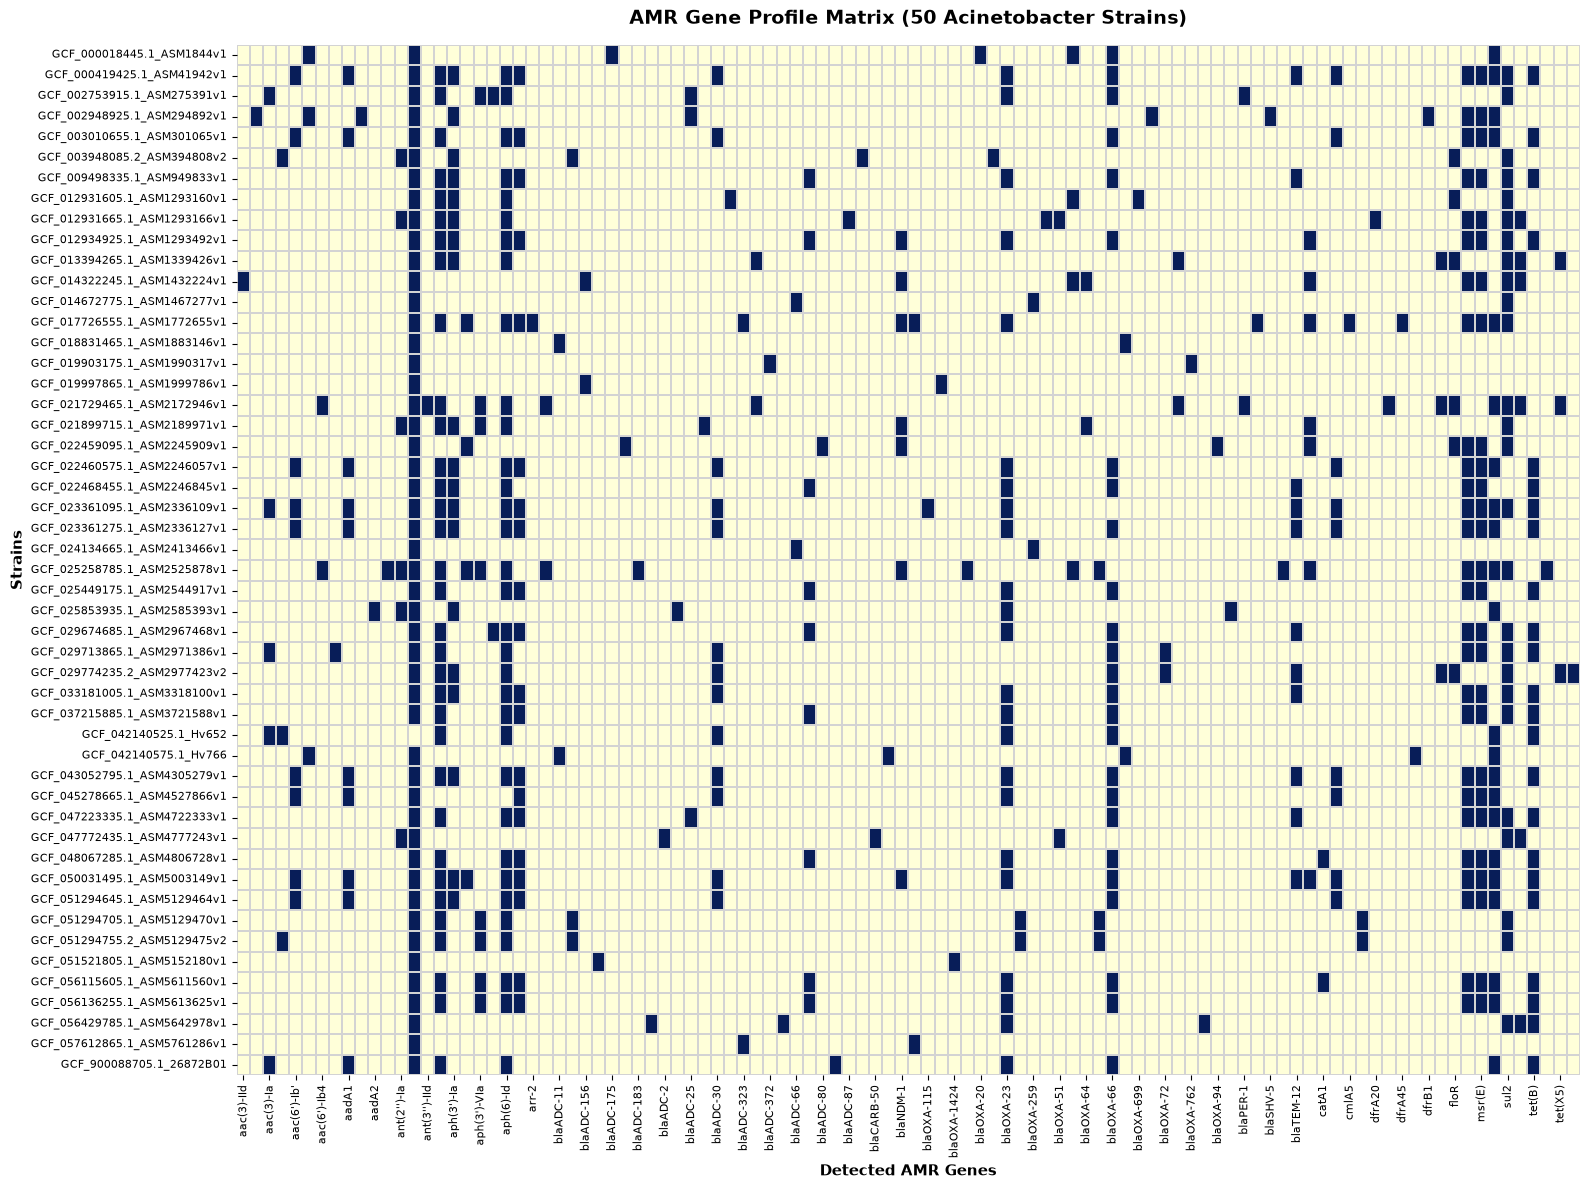

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Read ABRicate summary report
df = pd.read_csv('amr_summary.tsv', sep='\t', index_col=0)

# 2. Clean strain names for clean axis labels
df.index = df.index.str.replace('my_genomes/', '', regex=False).str.replace('_genomic.fna', '', regex=False)

# 3. Drop metadata column if present
if 'NUM_FOUND' in df.columns:
    df = df.drop(columns=['NUM_FOUND'])

# 4. Convert table to binary presence (1) / absence (0)
# Vectorized approach compatible with Pandas 2.x and 3.x
binary_df = (df.notna() & (df != '.')).astype(int)

# 5. Render Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(binary_df, cmap="YlGnBu", cbar=False, linewidths=0.2, linecolor='lightgray')

plt.title("AMR Gene Profile Matrix (50 Acinetobacter Strains)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Detected AMR Genes", fontsize=11, fontweight='bold')
plt.ylabel("Strains", fontsize=11, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('amr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 📝 Conclusion: Antimicrobial Resistance (AMR) Profiling

1. **Widespread Resistance Determinants**: Screening revealed a dense landscape of AMR genes, led by highly conserved aminoglycoside resistance markers such as `ant(2'')-Ia` across nearly all 50 strains.
2. **Critical Carbapenemase Burden**: Key carbapenem-hydrolyzing $\beta$-lactamases were identified, including intrinsic/acquired `blaOXA` variants (`blaOXA-23`, `blaOXA-66`) as well as high-risk metallo-$\beta$-lactamases (`blaNDM-1`) in specific epidemic lineages.
3. **Multidrug Resistance (MDR) Co-occurrence**: Distinct co-occurrence blocks of `sul2`, `tet(B)`, and `msr(E)` suggest active acquisition of mobile genetic elements conferring multi-class antibiotic resistance.